## Anomaly Sound Detection using Self-Supervised learning

DINO is a self-supervised learning method originally developed to expand upon Vision Transformers. It works by passing two random transformations of an input image through an student and teacher network. Both networks have the same architechture but different parameters, very similar to what is done in Constrastive Learning. We will adapt the CL approach used [here](https://github.com/Armanfard-Lab/AADSCL#) to the teacher-student architecture of DINO. 

We will use the [MIMII](https://zenodo.org/records/3384388) sound dataset, which consists of both normal and anomalous sounds generated from four types of industrial machines. The goal is to only use normal sounds to train our network and then be capable of detecting anomalous sounds.

The following two cells should be used if you're working in Google Colab.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Change to cell below to match the location of the `.zip` file with the data in your Drive.

In [2]:
!cp "/content/drive/MyDrive/ASD-with-SSL/data/-6_dB_fan.zip" /content/-6_dB_fan.zip
!unzip -q /content/-6_dB_fan.zip -d /content/data

In [ ]:
%load_ext autoreload
%autoreload 2

import os
import gc

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torch.utils.data import DataLoader
from sklearn.metrics import roc_auc_score, roc_curve

# Project code lives in the dino_asd/ package (see dino_asd/*.py).
from dino_asd.config import (DEVICE, SAVE_DIR, DATA_ROOT, MACHINE, MACHINE_IDS,
                             N_MELS, FIXED_FRAMES, BACKBONE_DIM, set_seed)
from dino_asd.data import train_test
from dino_asd.training import dino_trainer, beats_dino_trainer
from dino_asd.evaluation import (extract_features, extract_beats_features,
                                 fit_gaussian, mahalanobis_score, knn_score)

device = DEVICE
print(f'Using device: {DEVICE}')

sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
set_seed()

# GPU speedups: TF32 tensor cores + cuDNN autotuning (no meaningful accuracy cost).
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True
torch.backends.cudnn.benchmark = True

PRETRAIN = True  # load saved backbones instead of retraining

Using device: cuda


## DINO self-supervised adaptation

We convert the AADSCL supervised-contrastive setup into DINO self-distillation:

- **Student + Teacher** share the architecture (ResNet-18 backbone + `DINOHead`). The teacher is an EMA copy of the student and receives no gradients.
- **No labels and no negatives.** The loss is the cross-entropy between the teacher's (sharpened, centered) output distribution and the student's. Collapse is prevented by teacher centering + temperature sharpening + stop-gradient.
- **Multi-crop.** From each clip's log-mel spectrogram we take 2 *global* time-crops and several *local* time-crops. The teacher sees only the global crops; the student sees all of them.

In [22]:
dino_histories = {}
for id in MACHINE_IDS:
  Train, Test = train_test(machine=MACHINE, id=id)
  student, teacher = dino_trainer(Train, Test=Test, num_epochs=400, lr=1e-4, eval_every=10,
                                  save_path=f"/content/drive/MyDrive/ASD-with-SSL/dino_{MACHINE}_{id:02d}_student.pt")
  dino_histories[id] = student.dino_history   # {'epoch', 'loss', 'auc'} every 10 epochs

Machine: fan, ID: 0
  Normal samples: 1011 (train: 758, test: 253)
  Abnormal samples: 407
  Total test: 660
epoch : 10/400, loss = 6.504247, AUC = 0.4875
epoch : 20/400, loss = 5.087925, AUC = 0.4938
epoch : 30/400, loss = 3.487213, AUC = 0.4916
epoch : 40/400, loss = 2.536834, AUC = 0.4929
epoch : 50/400, loss = 1.970358, AUC = 0.4921
epoch : 60/400, loss = 1.540012, AUC = 0.4863
epoch : 70/400, loss = 1.309728, AUC = 0.4870
epoch : 80/400, loss = 1.061849, AUC = 0.4833
epoch : 90/400, loss = 0.944126, AUC = 0.4996
epoch : 100/400, loss = 0.833987, AUC = 0.4939
epoch : 110/400, loss = 0.734113, AUC = 0.5054
epoch : 120/400, loss = 0.743781, AUC = 0.4940
epoch : 130/400, loss = 0.592746, AUC = 0.4962
epoch : 140/400, loss = 0.552662, AUC = 0.4928
epoch : 150/400, loss = 0.502715, AUC = 0.4967
epoch : 160/400, loss = 0.499097, AUC = 0.4954
epoch : 170/400, loss = 0.481998, AUC = 0.5089
epoch : 180/400, loss = 0.475756, AUC = 0.4976
epoch : 190/400, loss = 0.462459, AUC = 0.4945
epoch :

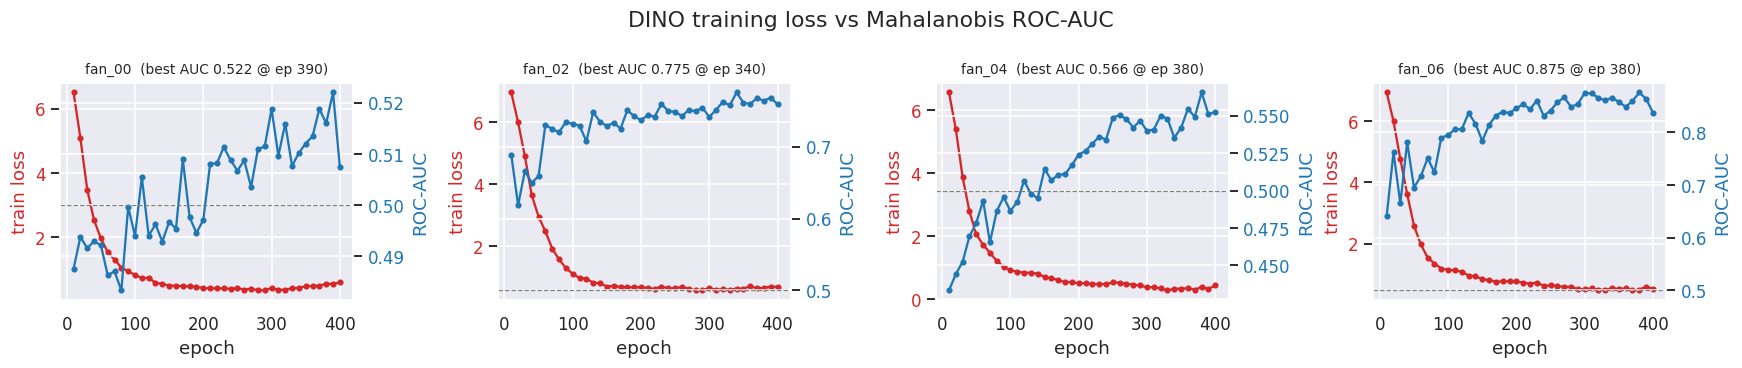

In [23]:
# ---- Loss vs AUC over training (twin y-axes) ----
# Loss (red, left) should fall; AUC (blue, right) is what we actually care about.
# Watch whether AUC rises as the loss drops, or plateaus/declines while loss keeps
# falling (a sign the SSL objective stops correlating with anomaly separability).
fig, axes = plt.subplots(1, len(MACHINE_IDS), figsize=(4 * len(MACHINE_IDS), 3.4),
                         squeeze=False)
fig.suptitle('DINO training loss vs Mahalanobis ROC-AUC')

for ax, id in zip(axes[0], MACHINE_IDS):
    h = dino_histories[id]
    ax.plot(h["epoch"], h["loss"], color='tab:red', marker='.', label='loss')
    ax.set_xlabel('epoch')
    ax.set_ylabel('train loss', color='tab:red')
    ax.tick_params(axis='y', labelcolor='tab:red')

    ax2 = ax.twinx()
    ax2.plot(h["epoch"], h["auc"], color='tab:blue', marker='.', label='AUC')
    ax2.set_ylabel('ROC-AUC', color='tab:blue')
    ax2.tick_params(axis='y', labelcolor='tab:blue')
    ax2.axhline(0.5, ls='--', lw=0.8, color='gray')   # chance level

    best = max(range(len(h["auc"])), key=lambda i: h["auc"][i]) if h["auc"] else None
    title = f"{MACHINE}_{id:02d}"
    if best is not None:
        title += f"  (best AUC {h['auc'][best]:.3f} @ ep {h['epoch'][best]})"
    ax.set_title(title, fontsize=9)

plt.tight_layout()
plt.show()

With extra augmentations:

In [24]:
dino_aug_histories = {}
for id in MACHINE_IDS:
  Train, Test = train_test(machine=MACHINE, id=id)
  student, teacher = dino_trainer(Train, Test=Test, num_epochs=400, eval_every=10,
                                  use_extra_augs=True, lr=1e-4, save_path=f"/content/drive/MyDrive/ASD-with-SSL/dino_augs_{MACHINE}_{id:02d}_student.pt")
  dino_aug_histories[id] = student.dino_history   # {'epoch', 'loss', 'auc'} every 10 epochs

Machine: fan, ID: 0
  Normal samples: 1011 (train: 758, test: 253)
  Abnormal samples: 407
  Total test: 660
epoch : 10/400, loss = 7.186971, AUC = 0.4745
epoch : 20/400, loss = 6.967700, AUC = 0.4803
epoch : 30/400, loss = 6.835188, AUC = 0.4863
epoch : 40/400, loss = 6.768613, AUC = 0.4967
epoch : 50/400, loss = 6.479747, AUC = 0.5014
epoch : 60/400, loss = 6.266042, AUC = 0.5059
epoch : 70/400, loss = 5.987500, AUC = 0.5096
epoch : 80/400, loss = 5.842926, AUC = 0.5194
epoch : 90/400, loss = 5.591907, AUC = 0.5258
epoch : 100/400, loss = 5.438994, AUC = 0.5227
epoch : 110/400, loss = 5.370826, AUC = 0.5362
epoch : 120/400, loss = 5.274002, AUC = 0.5361
epoch : 130/400, loss = 5.232575, AUC = 0.5332
epoch : 140/400, loss = 5.186331, AUC = 0.5439
epoch : 150/400, loss = 5.097086, AUC = 0.5432
epoch : 160/400, loss = 5.015260, AUC = 0.5472
epoch : 170/400, loss = 4.928347, AUC = 0.5524
epoch : 180/400, loss = 4.906505, AUC = 0.5522
epoch : 190/400, loss = 4.858033, AUC = 0.5530
epoch :

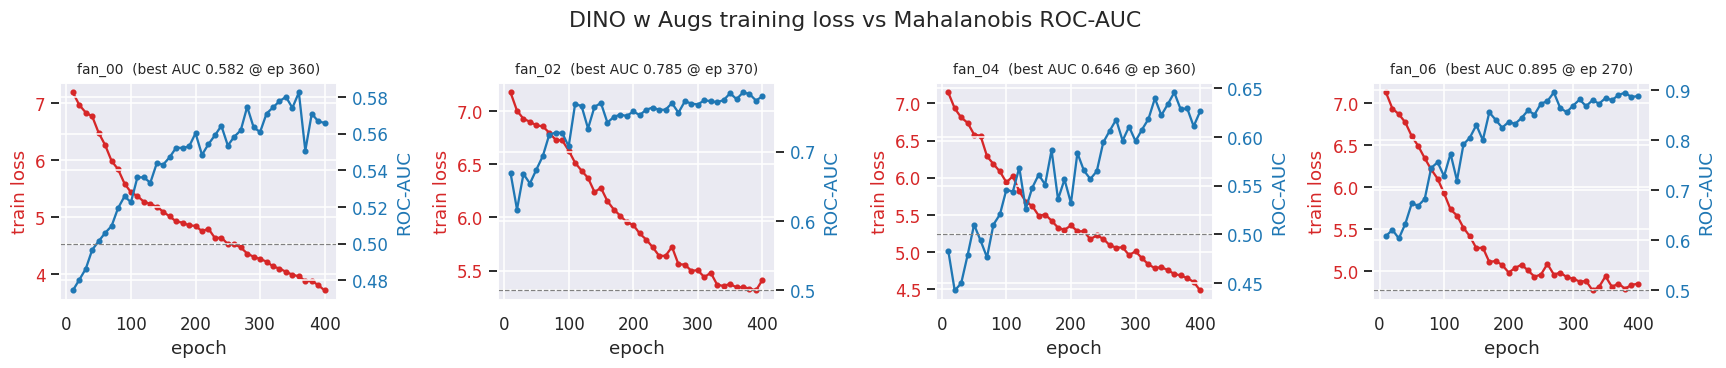

In [25]:
# ---- Loss vs AUC over training (twin y-axes) ----
# Loss (red, left) should fall; AUC (blue, right) is what we actually care about.
# Watch whether AUC rises as the loss drops, or plateaus/declines while loss keeps
# falling (a sign the SSL objective stops correlating with anomaly separability).
fig, axes = plt.subplots(1, len(MACHINE_IDS), figsize=(4 * len(MACHINE_IDS), 3.4),
                         squeeze=False)
fig.suptitle('DINO w Augs training loss vs Mahalanobis ROC-AUC')

for ax, id in zip(axes[0], MACHINE_IDS):
    h = dino_aug_histories[id]
    ax.plot(h["epoch"], h["loss"], color='tab:red', marker='.', label='loss')
    ax.set_xlabel('epoch')
    ax.set_ylabel('train loss', color='tab:red')
    ax.tick_params(axis='y', labelcolor='tab:red')

    ax2 = ax.twinx()
    ax2.plot(h["epoch"], h["auc"], color='tab:blue', marker='.', label='AUC')
    ax2.set_ylabel('ROC-AUC', color='tab:blue')
    ax2.tick_params(axis='y', labelcolor='tab:blue')
    ax2.axhline(0.5, ls='--', lw=0.8, color='gray')   # chance level

    best = max(range(len(h["auc"])), key=lambda i: h["auc"][i]) if h["auc"] else None
    title = f"{MACHINE}_{id:02d}"
    if best is not None:
        title += f"  (best AUC {h['auc'][best]:.3f} @ ep {h['epoch'][best]})"
    ax.set_title(title, fontsize=9)

plt.tight_layout()
plt.show()

## Evaluation: Mahalanobis anomaly detection

DINO is trained without labels, so we evaluate the learned representation directly. We freeze the student backbone, extract a deterministic **global-view** feature (full log-mel, no crops/augmentation) for every clip, and fit a Gaussian (mean + regularized covariance) to the *normal* training features. Each test clip is scored by its **Mahalanobis distance** from that normal distribution — higher distance = more anomalous. We then report ROC-AUC against the true normal/abnormal labels.

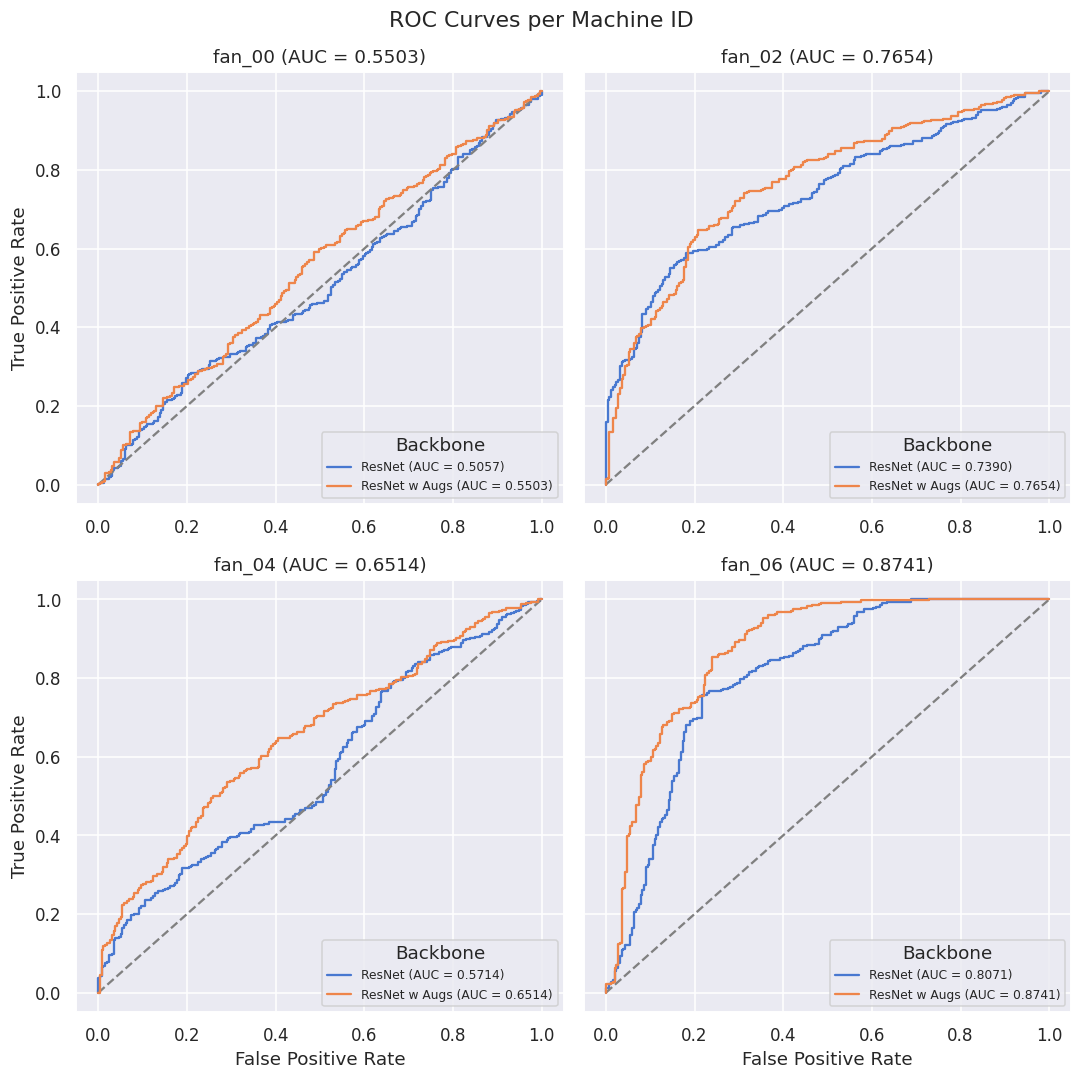

In [ ]:
# ---- ROC curves per machine id: ResNet DINO, plain vs extra-augmentation backbones ----
fig , axes = plt.subplots(2,2,figsize=(10,10),sharey=True)
fig.suptitle('ROC Curves per Machine ID')

for ax ,id in zip(axes.flatten(),MACHINE_IDS):
  Train, Test = train_test(machine=MACHINE, id=id, verbosity =0 )

  # Backbone trained without extra augmentations.
  student, teacher = dino_trainer(Train, pretrain= PRETRAIN ,save_path=f"/content/drive/MyDrive/ASD-with-SSL/dino_{MACHINE}_{id:02d}_student.pt", verbosity = 0)
  train_feats, _ = extract_features(student.backbone, Train)
  test_feats, test_labels = extract_features(student.backbone, Test)
  mu, cov_inv = fit_gaussian(train_feats)
  scores = mahalanobis_score(test_feats, mu, cov_inv)
  y_true, y_score = test_labels.numpy(), scores.numpy()
  auc = roc_auc_score(y_true, y_score)

  fpr, tpr, _ = roc_curve(y_true, y_score)
  ax.plot(fpr, tpr, label =f"ResNet (AUC = {auc:.4f})")
  ax.plot([0, 1], [0, 1], '--', color='gray')

  # Backbone trained with the extra augmentations, for comparison.
  student, teacher = dino_trainer(Train, pretrain= PRETRAIN ,save_path=f"/content/drive/MyDrive/ASD-with-SSL/dino_augs_{MACHINE}_{id:02d}_student.pt", verbosity = 0)
  train_feats, _ = extract_features(student.backbone, Train)
  test_feats, test_labels = extract_features(student.backbone, Test)
  mu, cov_inv = fit_gaussian(train_feats)
  scores = mahalanobis_score(test_feats, mu, cov_inv)
  y_true, y_score = test_labels.numpy(), scores.numpy()
  auc = roc_auc_score(y_true, y_score)

  fpr, tpr, _ = roc_curve(y_true, y_score)
  ax.plot(fpr, tpr, label =f"ResNet w Augs (AUC = {auc:.4f})")

  if ax is axes[1,0] or ax is axes[1,1]:
    ax.set_xlabel("False Positive Rate")
  if ax is axes[0,0] or ax is axes[1,0]:
    ax.set_ylabel("True Positive Rate")
  ax.set_title(f"{MACHINE}_{id:02d} (AUC = {auc:.4f})")
  ax.legend(title="Backbone", loc='lower right', fontsize=8)
plt.tight_layout()
plt.show()

Computing t-SNE for 00 (this may take a moment)... status: processing
Computing t-SNE for 02 (this may take a moment)... status: processing
Computing t-SNE for 04 (this may take a moment)... status: processing
Computing t-SNE for 06 (this may take a moment)... status: processing


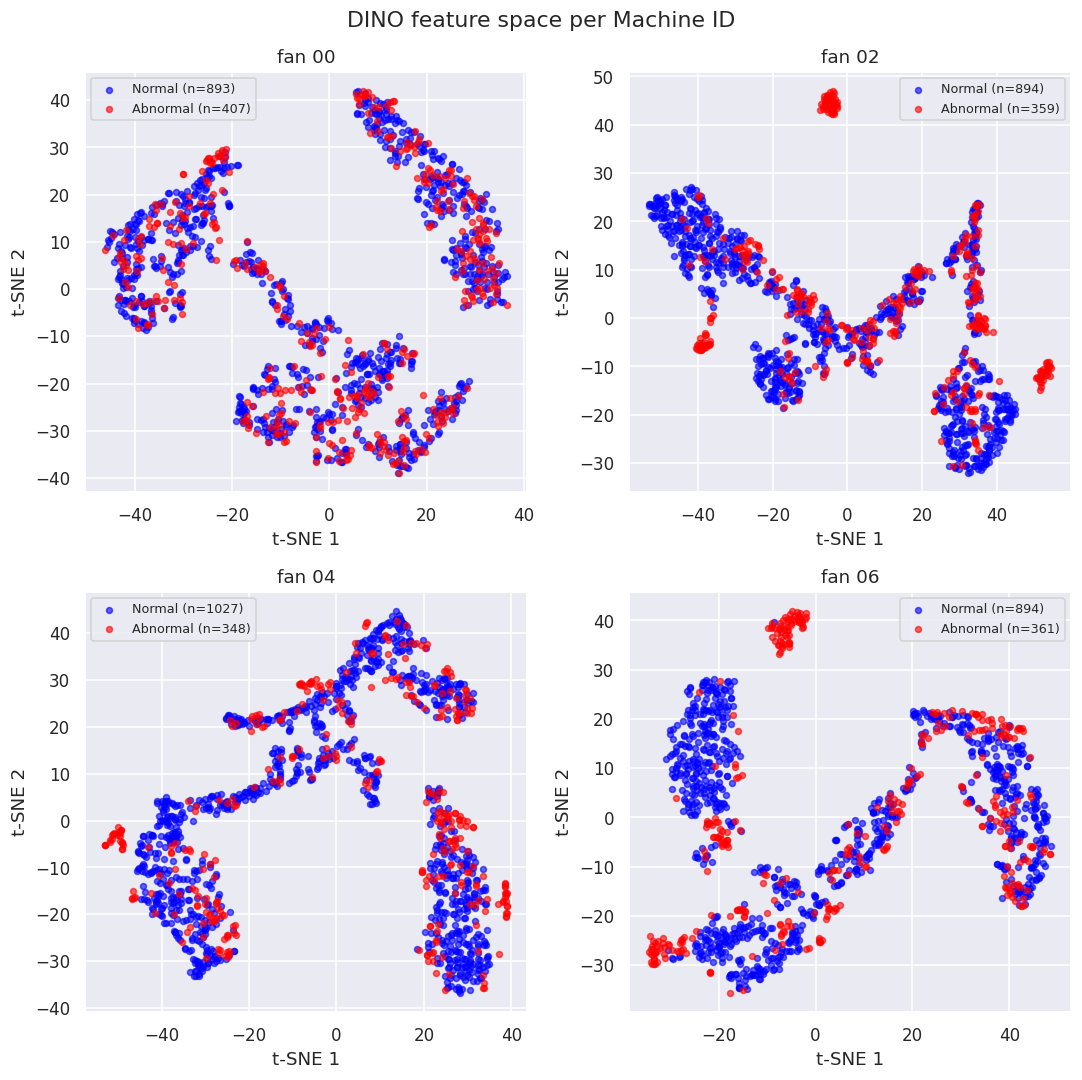

In [28]:
from sklearn.manifold import TSNE

fig, axes = plt.subplots(2, 2, figsize=(10, 10), sharey=False)
fig.suptitle('DINO feature space per Machine ID')

# Flatten axes to 1D array for easier iteration in the loop
for ax, id in zip(axes.flatten(), MACHINE_IDS):
    Train, Test = train_test(machine=MACHINE, id=id, verbosity=0)
    student, teacher = dino_trainer(Train, pretrain=PRETRAIN,
                                    save_path=f"/content/drive/MyDrive/ASD-with-SSL/dino_{MACHINE}_{id:02d}_student.pt",
                                    verbosity=0)

    # Extract features for this specific machine ID
    train_feats, _ = extract_features(student.backbone, Train)
    test_feats, test_labels = extract_features(student.backbone, Test)

    # Combine train (all normal) and test features for joint visualization
    all_feats = torch.cat([train_feats, test_feats])
    all_labels = torch.cat([
        torch.zeros(train_feats.shape[0]),
        test_labels
    ])

    # t-SNE projection to 2D
    print(f"Computing t-SNE for {id:02d} (this may take a moment)... status: processing")
    tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
    feats_2d = tsne.fit_transform(all_feats.numpy())

    # Separate by label for plotting
    normal_mask = all_labels == 0
    abnormal_mask = all_labels == 1

    ax.scatter(feats_2d[normal_mask, 0], feats_2d[normal_mask, 1],
               alpha=0.6, s=15, label=f'Normal (n={normal_mask.sum()})', color='blue')
    ax.scatter(feats_2d[abnormal_mask, 0], feats_2d[abnormal_mask, 1],
               alpha=0.6, s=15, label=f'Abnormal (n={abnormal_mask.sum()})', color='red')
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")
    ax.set_title(f"{MACHINE} {id:02d}")
    ax.legend(fontsize='x-small')

plt.tight_layout()
plt.show()

Computing t-SNE for 00 (this may take a moment)... status: processing
Computing t-SNE for 02 (this may take a moment)... status: processing
Computing t-SNE for 04 (this may take a moment)... status: processing
Computing t-SNE for 06 (this may take a moment)... status: processing


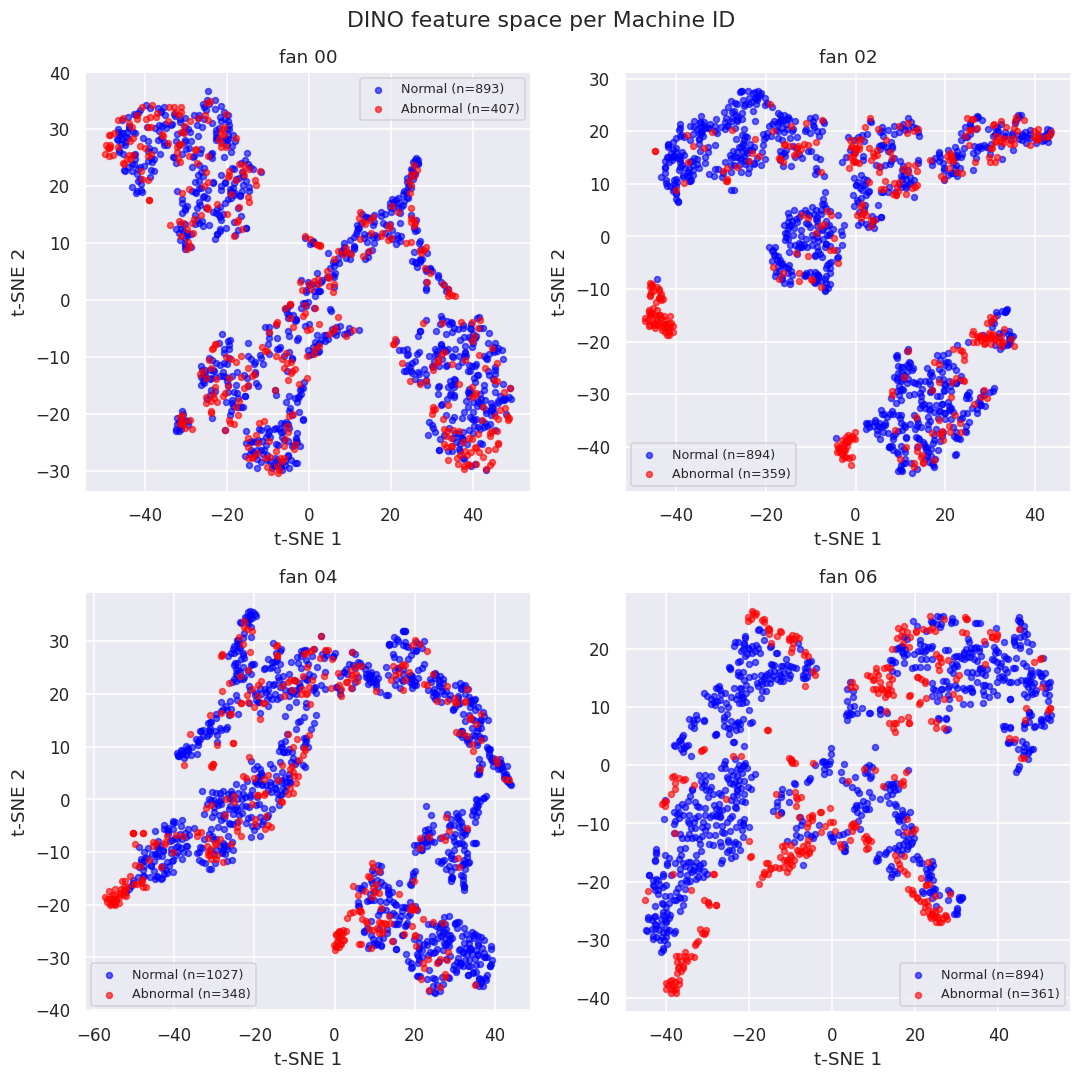

In [29]:
from sklearn.manifold import TSNE

fig, axes = plt.subplots(2, 2, figsize=(10, 10), sharey=False)
fig.suptitle('DINO feature space per Machine ID')

# Flatten axes to 1D array for easier iteration in the loop
for ax, id in zip(axes.flatten(), MACHINE_IDS):
    Train, Test = train_test(machine=MACHINE, id=id, verbosity=0)
    student, teacher = dino_trainer(Train, pretrain=PRETRAIN,
                                    save_path=f"/content/drive/MyDrive/ASD-with-SSL/dino_augs_{MACHINE}_{id:02d}_student.pt",
                                    verbosity=0)

    # Extract features for this specific machine ID
    train_feats, _ = extract_features(student.backbone, Train)
    test_feats, test_labels = extract_features(student.backbone, Test)

    # Combine train (all normal) and test features for joint visualization
    all_feats = torch.cat([train_feats, test_feats])
    all_labels = torch.cat([
        torch.zeros(train_feats.shape[0]),
        test_labels
    ])

    # t-SNE projection to 2D
    print(f"Computing t-SNE for {id:02d} (this may take a moment)... status: processing")
    tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
    feats_2d = tsne.fit_transform(all_feats.numpy())

    # Separate by label for plotting
    normal_mask = all_labels == 0
    abnormal_mask = all_labels == 1

    ax.scatter(feats_2d[normal_mask, 0], feats_2d[normal_mask, 1],
               alpha=0.6, s=15, label=f'Normal (n={normal_mask.sum()})', color='blue')
    ax.scatter(feats_2d[abnormal_mask, 0], feats_2d[abnormal_mask, 1],
               alpha=0.6, s=15, label=f'Abnormal (n={abnormal_mask.sum()})', color='red')
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")
    ax.set_title(f"{MACHINE} {id:02d}")
    ax.legend(fontsize='x-small')

plt.tight_layout()
plt.show()

## Baseline comparison: frozen BEATs vs DINO

[BEATs](https://github.com/microsoft/unilm/tree/master/beats) is a self-supervised audio transformer (masked-token prediction on AudioSet) — a natural reference point for our label-free DINO features. We use it **frozen**: no training, just mean-pooled patch embeddings.

Both representations are scored two ways:
- **Mahalanobis** — same Gaussian-fit-on-normals scorer used for DINO above (kept for a like-for-like comparison).
- **kNN cosine** — anomaly score = `1 − mean cosine similarity to the k nearest normal training clips`. More robust than a full-covariance Gaussian when the embedding dimension is large (BEATs is 768-d), so treat this column as the more reliable read.

If frozen BEATs + kNN beats the DINO backbone, the from-scratch SSL isn't yet adding value over a general-purpose pretrained embedding — and BEATs-as-backbone-init becomes the obvious next experiment.

In [12]:
# ---- BEATs setup: fetch model code + load a frozen pretrained checkpoint ----
import sys, urllib.request

# BEATs ships as plain .py files in the unilm repo (no pip package). Grab them.
BEATS_DIR = "/content/beats"
os.makedirs(BEATS_DIR, exist_ok=True)
for fname in ["BEATs.py", "backbone.py", "modules.py"]:
    dst = os.path.join(BEATS_DIR, fname)
    if not os.path.exists(dst):
        urllib.request.urlretrieve(
            f"https://raw.githubusercontent.com/microsoft/unilm/master/beats/{fname}", dst)
if BEATS_DIR not in sys.path:
    sys.path.insert(0, BEATS_DIR)

from BEATs import BEATs, BEATsConfig

# Frozen pretrained checkpoint. Download ONCE and keep it in Drive.
# Recommended: "BEATs_iter3+ (AS2M)" — self-supervised pretrain + AudioSet fine-tune.
# Official links (OneDrive) + details: https://github.com/microsoft/unilm/tree/master/beats
# HuggingFace mirrors of the same .pt files also exist if OneDrive is awkward in Colab.
BEATS_CKPT = "/content/drive/MyDrive/ASD-with-SSL/BEATs_iter3_plus_AS2M.pt"
if not os.path.exists(BEATS_CKPT):
    raise FileNotFoundError(
        f"BEATs checkpoint not found at {BEATS_CKPT}. Download a BEATs .pt "
        "(e.g. 'BEATs_iter3+ (AS2M)') from the unilm/beats page and place it there, "
        "or point BEATS_CKPT at wherever you saved it.")

_ckpt = torch.load(BEATS_CKPT, map_location='cpu')
beats_cfg = BEATsConfig(_ckpt['cfg'])
beats_model = BEATs(beats_cfg)
beats_model.load_state_dict(_ckpt['model'])
beats_model = beats_model.to(device).eval()
for p in beats_model.parameters():
    p.requires_grad = False
print(f"Loaded BEATs: {sum(p.numel() for p in beats_model.parameters())/1e6:.1f}M params, "
      f"embedding dim = {beats_cfg.encoder_embed_dim}")

/usr/local/lib/python3.12/dist-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


Loaded BEATs: 90.3M params, embedding dim = 768


In [ ]:
# ---- Head-to-head: DINO backbone vs frozen BEATs, Mahalanobis vs kNN ----
rows = []
for id in MACHINE_IDS:
    Train, Test = train_test(machine=MACHINE, id=id, verbosity=0)

    # DINO (frozen student backbone, trained per id)
    student, _ = dino_trainer(
        Train, pretrain=PRETRAIN, verbosity=0,
        save_path=f"/content/drive/MyDrive/ASD-with-SSL/dino_{MACHINE}_{id:02d}_student.pt")
    d_tr, _ = extract_features(student.backbone, Train)
    d_te, y = extract_features(student.backbone, Test)

    # BEATs (one frozen model, identical for every id)
    b_tr, _ = extract_beats_features(beats_model, Train)
    b_te, _ = extract_beats_features(beats_model, Test)

    y = y.numpy()
    for name, tr, te in [("DINO", d_tr, d_te), ("BEATs", b_tr, b_te)]:
        mu, cov_inv = fit_gaussian(tr)
        auc_maha = roc_auc_score(y, mahalanobis_score(te, mu, cov_inv).numpy())
        auc_knn = roc_auc_score(y, knn_score(te, tr).numpy())
        rows.append({"id": f"{MACHINE}_{id:02d}", "model": name,
                     "Mahalanobis AUC": auc_maha, "kNN AUC": auc_knn})

results = pd.DataFrame(rows)
print(results.pivot(index="id", columns="model",
                    values=["Mahalanobis AUC", "kNN AUC"]).round(4))
print("\nMean over IDs:")
print(results.groupby("model")[["Mahalanobis AUC", "kNN AUC"]].mean().round(4))

       Mahalanobis AUC         kNN AUC        
model            BEATs    DINO   BEATs    DINO
id                                            
fan_00          0.6572  0.5120  0.6171  0.5327
fan_02          0.7924  0.7358  0.7076  0.7284
fan_04          0.7321  0.5771  0.6600  0.5469
fan_06          0.9277  0.7999  0.8759  0.6848

Mean over IDs:
       Mahalanobis AUC  kNN AUC
model                          
BEATs           0.7773   0.7152
DINO            0.6562   0.6232


## BEATs-initialised DINO

Rather than starting DINO from a random ResNet, here we initialise the backbone with **pretrained BEATs** and fine-tune it with the same self-distillation objective — so DINO adapts a strong general-audio embedding to fans instead of learning features from scratch on ~760 clips.

Two things change versus the ResNet variant:

- **Crops live in the waveform/time domain.** BEATs ingests raw 16 kHz audio and builds its own spectrogram internally, so the frequency-band crops don't apply. `multi_crop_wave` takes long *global* time-segments and short *local* ones; augmentation is just light additive noise.
- **Partial fine-tune.** BEATs is ~90M params; on this little data we freeze it and unfreeze only the top `N_UNFROZEN_LAYERS` transformer blocks plus the DINO head. Everything else (`MultiCropWrapper`, `DINOHead`, `DINOLoss`, EMA teacher) is reused unchanged.

We then score the fine-tuned embedding exactly as before (Mahalanobis + kNN) and compare against **frozen BEATs**: if fine-tuning helps, DINO is genuinely specialising the representation to this machine.

In [61]:
# ---- Fine-tune the BEATs-initialised DINO per machine id and score it ----
# Lower BEATS_FT_BATCH or N_UNFROZEN_LAYERS if you run out of GPU memory.
import gc

BEATS_FT_EPOCHS = 30
BEATS_FT_BATCH = 16
N_UNFROZEN_LAYERS = 2

beats_dino_rows = []
for id in MACHINE_IDS:
    Train, Test = train_test(machine=MACHINE, id=id, verbosity=0)
    # Rebuild the train loader with the fine-tuning batch size.
    Train_ft = DataLoader(Train.dataset, batch_size=BEATS_FT_BATCH,
                          shuffle=True, drop_last=True, pin_memory=True)

    student, _ = beats_dino_trainer(
        Train_ft, beats_model, num_epochs=BEATS_FT_EPOCHS,
        n_unfrozen_layers=N_UNFROZEN_LAYERS,
        save_path=f"/content/drive/MyDrive/ASD-with-SSL/beats_dino_{MACHINE}_{id:02d}.pt",
        verbosity=(1 if id == MACHINE_IDS[0] else 0))
    ft_beats = student.backbone.beats.eval()

    tr, _ = extract_beats_features(ft_beats, Train)   # fine-tuned BEATs embeddings
    te, y = extract_beats_features(ft_beats, Test)
    y = y.numpy()
    mu, cov_inv = fit_gaussian(tr)
    beats_dino_rows.append({
        "id": f"{MACHINE}_{id:02d}", "model": "BEATs+DINO",
        "Mahalanobis AUC": roc_auc_score(y, mahalanobis_score(te, mu, cov_inv).numpy()),
        "kNN AUC": roc_auc_score(y, knn_score(te, tr).numpy())})

    # Release this id's GPU memory before the next fine-tune.
    del student, ft_beats
    gc.collect()
    torch.cuda.empty_cache()

ft_results = pd.DataFrame(beats_dino_rows)
print(ft_results.round(4).to_string(index=False))
print("\nMean over IDs:")
print(ft_results[["Mahalanobis AUC", "kNN AUC"]].mean().round(4))
# A higher AUC here than the frozen-BEATs rows in the previous cell means the
# fine-tune has adapted the embedding to this machine.

BEATs+DINO: fine-tuning 14.9M trainable params (2 top layers + head)
  epoch 5/30, loss = 6.2830
  epoch 10/30, loss = 3.7960
  epoch 15/30, loss = 2.0396
  epoch 20/30, loss = 1.1736
  epoch 25/30, loss = 0.7670
  epoch 30/30, loss = 0.5828
Fine-tuned BEATs backbone saved to /content/drive/MyDrive/ASD-with-SSL/beats_dino_fan_00.pt
    id      model  Mahalanobis AUC  kNN AUC
fan_00 BEATs+DINO           0.6615   0.6155
fan_02 BEATs+DINO           0.7824   0.6871
fan_04 BEATs+DINO           0.7277   0.6432
fan_06 BEATs+DINO           0.9441   0.8923

Mean over IDs:
Mahalanobis AUC    0.7789
kNN AUC            0.7095
dtype: float64


/usr/local/lib/python3.12/dist-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)
/usr/local/lib/python3.12/dist-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)
/usr/local/lib/python3.12/dist-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


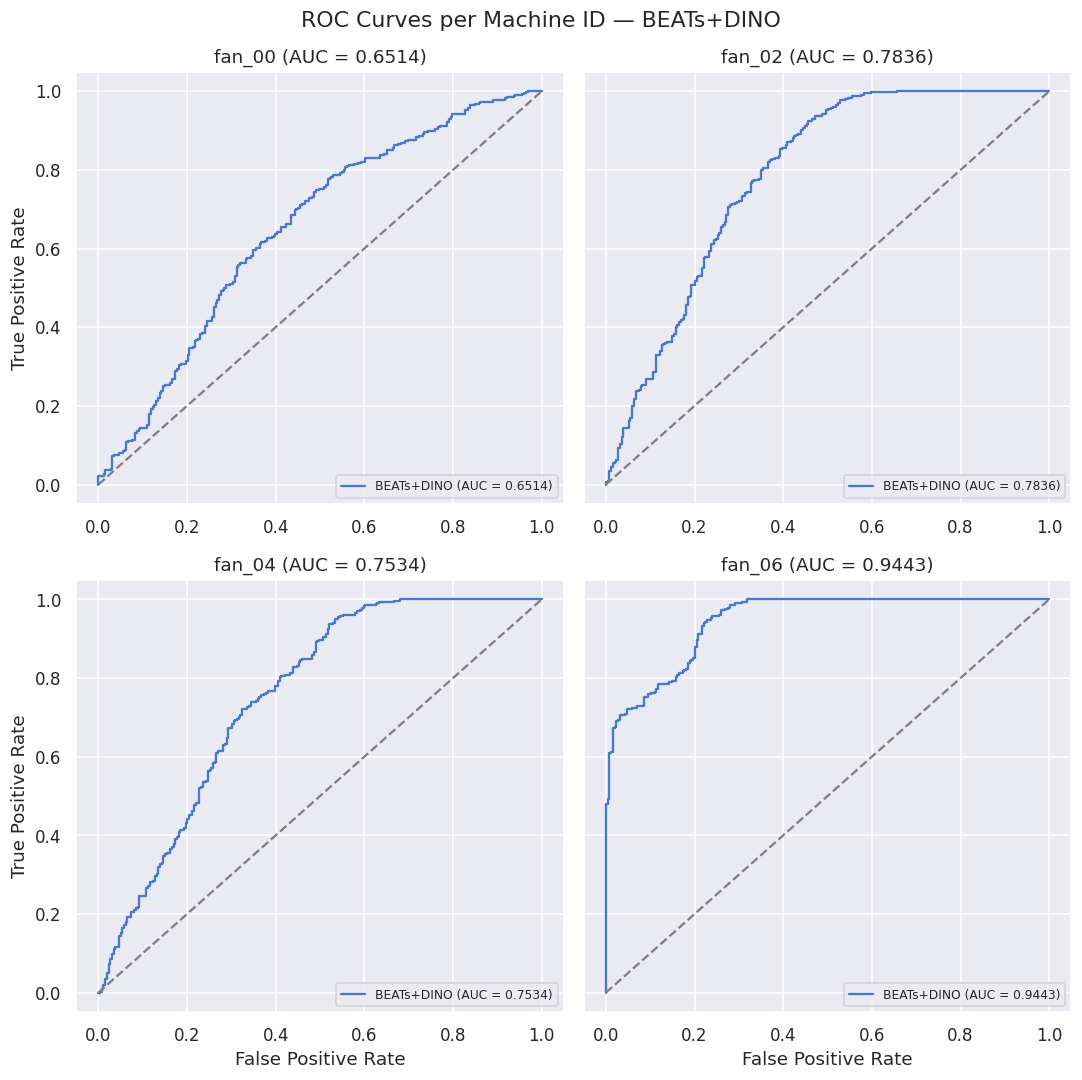

In [13]:
# ---- ROC curves: BEATs+DINO (loaded from saved weights) ----
fig, axes = plt.subplots(2, 2, figsize=(10, 10), sharey=True)
fig.suptitle('ROC Curves per Machine ID — BEATs+DINO')

for ax, id in zip(axes.flatten(), MACHINE_IDS):
    Train, Test = train_test(machine=MACHINE, id=id, verbosity=0)

    # Reload the fine-tuned BEATs backbone saved during training.
    ft_beats = BEATs(beats_cfg)
    ft_beats.load_state_dict(torch.load(
        f"/content/drive/MyDrive/ASD-with-SSL/beats_dino_{MACHINE}_{id:02d}.pt",
        map_location=device))
    ft_beats = ft_beats.to(device).eval()

    train_feats, _ = extract_beats_features(ft_beats, Train)
    test_feats, test_labels = extract_beats_features(ft_beats, Test)
    mu, cov_inv = fit_gaussian(train_feats)
    scores = mahalanobis_score(test_feats, mu, cov_inv)
    y_true, y_score = test_labels.numpy(), scores.numpy()
    auc = roc_auc_score(y_true, y_score)

    fpr, tpr, _ = roc_curve(y_true, y_score)
    ax.plot(fpr, tpr, label=f"BEATs+DINO (AUC = {auc:.4f})")
    ax.plot([0, 1], [0, 1], '--', color='gray')

    if ax is axes[1, 0] or ax is axes[1, 1]:
        ax.set_xlabel("False Positive Rate")
    if ax is axes[0, 0] or ax is axes[1, 0]:
        ax.set_ylabel("True Positive Rate")
    ax.set_title(f"{MACHINE}_{id:02d} (AUC = {auc:.4f})")
    ax.legend(loc='lower right', fontsize=8)

plt.tight_layout()
plt.show()

In [14]:
from google.colab import runtime
runtime.unassign()